In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data
df = pd.read_csv('iphone_purchase_records.csv')

# Encode Gender: Male=1, Female=0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Features and target
X = df[['Gender', 'Age', 'Salary']]
y = df['Purchase Iphone']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.925

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Load data
df = pd.read_csv('iphone_purchase_records.csv')

# Encode Gender: Male=1, Female=0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Features and target
X = df[['Gender', 'Age', 'Salary']]
y = df['Purchase Iphone']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define KNN and parameter grid
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': list(range(1, 21))}  # Test k from 1 to 20

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best k
best_k = grid_search.best_params_['n_neighbors']
print("Best k:", best_k)

# Train KNN with best k
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

# Predict
y_pred = best_knn.predict(X_test)

# Accuracy and report
accuracy = accuracy_score(y_test, y_pred)
accuracy
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Best k: 7
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



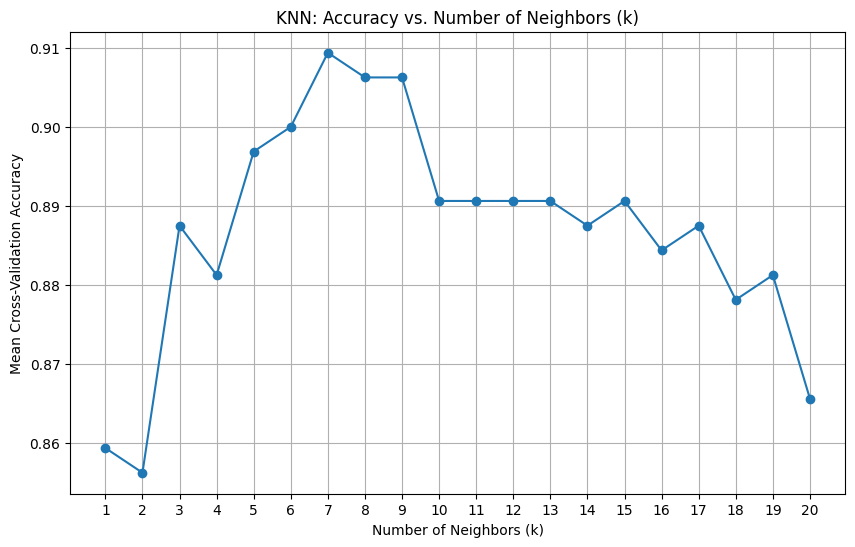

In [6]:
import matplotlib.pyplot as plt

# Get mean cross-validation scores for each k
cv_results = grid_search.cv_results_
mean_test_scores = cv_results['mean_test_score']
k_values = param_grid['n_neighbors']

# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_test_scores, marker='o')
plt.title('KNN: Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

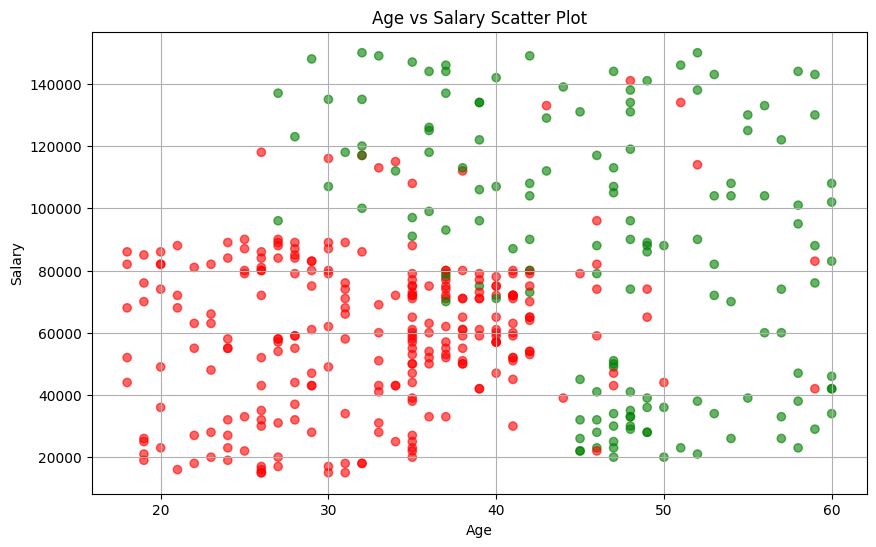

In [7]:
# Scatter plot
plt.figure(figsize=(10, 6))
colors = {0: 'red', 1: 'green'}  # No = red, Yes = green

plt.scatter(df['Age'], df['Salary'], c=df['Purchase Iphone'].map(colors), alpha=0.6)
plt.title('Age vs Salary Scatter Plot')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

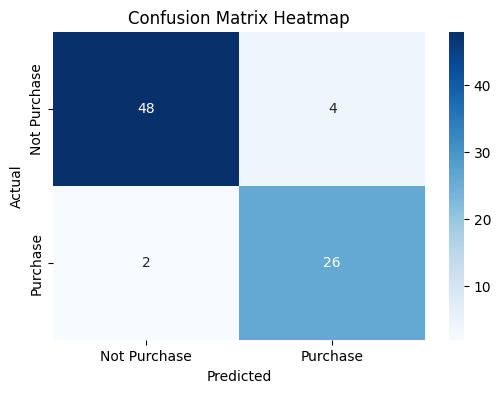

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Purchase', 'Purchase'], yticklabels=['Not Purchase', 'Purchase'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()